# Benchmark — March 2024
**File:** `benchmark_mar2024.ipynb` (renamed from `benchmarking_0304.ipynb`)

## Purpose
Early benchmarking run evaluating entropy similarity performance against the MoNA/NIST23 reference database. Establishes baseline ROC-AUC for the MS2 matching step before the Bayesian scoring layer was built.

## What is done
- Parses NIST23 MSP file and MoNA spectra into a unified DataFrame
- Computes pairwise entropy similarity between experimental and library spectra
- Evaluates ROC-AUC for correct vs incorrect compound matching
- Compares entropy similarity against peak-by-peak matching

## Status
ARCHIVED — Superseded by `proposal_mvp.ipynb`. Retained as reference for baseline MS2-only benchmark numbers.

## Key finding
Entropy similarity ROC-AUC ≈ 0.69 on MoNA QTOF. Peak-by-peak AUC ≈ 0.685. Entropy preferred; methods are complementary.


In [1]:
import numpy as np
import pandas as pd
import os
import ms_entropy as me


# Standard mapping for column names
standard_mapping = {
    "name": "Name",
    "ion_mode": "Ion Mode",
    "instrument": "Instrument",
    "instrument_type": "Instrument Type",
    "ionization": "Ionization",
    "collision_energy": "Collision Energy",
    "collision_gas": "Collision Gas",
    "sample_inlet": "Sample Inlet",
    "spectrum_type": "Spectrum Type",
    "precursor_type": "Precursor Type",
    "precursormz": "Precursor M/Z",
    "notes": "Notes",
    "inchikey": "InChIKey",
    "smiles": "SMILES",
    "synon": "Synonyms",
    "formula": "Formula",
    "mw": "Molecular Weight",
    "exactmass": "Exact Mass",
    "cas#": "CAS Number",
    "nist#": "NIST Number",
    "db#": "Database ID",
    "comments": "Comments",
    "unique_scan_number": "Unique Scan Number",
    "spectrum_id": "Spectrum ID",
    "num peaks": "Num Peaks"
}

def standardize_col(df):
    """
    Standardizes column names based on the provided mapping.

    Args:
        df (pd.DataFrame): The DataFrame whose column names need to be standardized.

    Returns:
        pd.DataFrame: DataFrame with standardized column names.
    """
    new_columns = []
    for col in df.columns:
        col_lower = col.lower().replace("reference_", "")
        standardized_col = standard_mapping.get(col_lower, col_lower)
        new_columns.append(standardized_col)
    df.columns = new_columns
    return df

def remove_zero_ions(msms):
    """
    Removes zero-intensity ions from an MS/MS spectrum.

    Args:
        msms (numpy.ndarray or float): MS/MS spectrum as a 2D NumPy array.

    Returns:
        numpy.ndarray: Filtered 2D array with non-zero intensities.
    """
    if isinstance(msms, float) or len(msms) == 0:
        return np.nan
    return msms[msms[:, 1] > 0]

def sort_spectrum(msms):
    """
    Sorts MS/MS peaks by m/z value.

    Args:
        msms (numpy.ndarray): 2D numpy array with [m/z, intensity].

    Returns:
        numpy.ndarray: Sorted 2D array.
    """
    if isinstance(msms, float) or len(msms) == 0:
        return np.nan
    return msms[np.argsort(msms[:, 0])]

def read_msp(file_path):
    """
    Parses an MSP file and extracts MS/MS spectra into a structured pandas DataFrame.

    Args:
        file_path (str): Path to the MSP file.

    Returns:
        pd.DataFrame: Parsed MS/MS spectra with metadata.
    """

    spectra = []
    spectrum = {}

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            if not line:
                continue  # Skip empty lines

            # Identify metadata fields
            if ":" in line:
                key, value = line.split(":", 1)
                key, value = key.strip().lower(), value.strip()

                if key == 'name':
                    # Save the previous spectrum before starting a new one
                    if spectrum:
                        spectra.append(spectrum)
                    spectrum = {'name': value, 'peaks': []}  # Start new spectrum entry
                
                else:
                    spectrum[key] = value  # Store metadata fields
            
            # Parse peak data (if line starts with a number, it's peak data)
            elif line[0].isdigit():
                try:
                    m_z, intensity = map(float, line.split()[:2])
                    spectrum['peaks'].append([m_z, intensity])
                except ValueError:
                    continue  # Ignore malformed lines

        # Save the last spectrum
        if spectrum:
            spectra.append(spectrum)

    # Convert spectra list to DataFrame
    df = pd.DataFrame(spectra)

    # Process peaks: Remove zero-intensity ions & sort by m/z
    df['peaks'] = [sort_spectrum(remove_zero_ions(np.array(peak))) for peak in df['peaks']]

    # Standardize column names
    df = standardize_col(df)

    # Convert numeric columns where applicable
    for column in df.columns:
        if column != 'peaks':  # Skip 'peaks' column
            try:
                df[column] = pd.to_numeric(df[column], errors='ignore')
            except:
                pass

    return df


In [2]:
# # Path to the MSP file
# file_path = "/Users/ellayoung/Desktop/metabolo_confi_score/data/nist23-raw.msp"

# # Parse the MSP file
# df = read_msp(file_path)

# # Display parsed data
# print(df.head())
# df.info()

# # Save to CSV
# df.to_csv("parsed_spectra.csv", index=False)


In [2]:
df = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/parsed_spectra.csv')

/var/folders/xd/3y34jslx1fsf1k1pd0bz8w3r0000gn/T/ipykernel_11614/446800534.py:1: DtypeWarning: Columns (11,28,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/parsed_spectra.csv')


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1934658 entries, 0 to 1934657
Data columns (total 31 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Name                object 
 1   peaks               object 
 2   Ion Mode            object 
 3   Instrument          object 
 4   Instrument Type     object 
 5   Ionization          object 
 6   Collision Energy    object 
 7   Collision Gas       object 
 8   Sample Inlet        object 
 9   Spectrum Type       object 
 10  Precursor Type      object 
 11  Precursor M/Z       object 
 12  Notes               object 
 13  InChIKey            object 
 14  SMILES              object 
 15  Synonyms            object 
 16  Formula             object 
 17  Molecular Weight    int64  
 18  Exact Mass          float64
 19  CAS Number          object 
 20  NIST Number         int64  
 21  Database ID         int64  
 22  Comments            object 
 23  Unique Scan Number  int64  
 24  Spectrum ID         int6

In [4]:
df_clean = df.iloc[:, [0, 1, 10, 18, 13, 14, 16, 24]]

In [ ]:
df_clean = df.iloc[:, [0, 1, 10, 18, 13, 14, 16, 24]]

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1934658 entries, 0 to 1934657
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Name            object 
 1   peaks           object 
 2   Precursor Type  object 
 3   Exact Mass      float64
 4   InChIKey        object 
 5   SMILES          object 
 6   Formula         object 
 7   Spectrum ID     int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 118.1+ MB


In [15]:
# only include entries with M+H or M-H adducts

df_clean_mh = df_clean[df_clean["Precursor Type"].isin(["[M+H]+", "[M-H]-"])]

In [10]:
df_clean_mh.info()

<class 'pandas.core.frame.DataFrame'>
Index: 773947 entries, 0 to 1934649
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Name            773947 non-null  object 
 1   peaks           773947 non-null  object 
 2   Precursor Type  773947 non-null  object 
 3   Exact Mass      773333 non-null  float64
 4   InChIKey        760653 non-null  object 
 5   SMILES          757768 non-null  object 
 6   Formula         773947 non-null  object 
 7   Spectrum ID     773947 non-null  int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 53.1+ MB


In [16]:
df_unique = df_clean_mh.dropna(subset=['InChIKey'])
df_unique = df_unique.drop_duplicates(subset=['InChIKey'], keep='first')
# # Convert NaN or float SMILES to empty strings and ensure dtype is string
df_unique["SMILES"] = df_unique["SMILES"].fillna("").astype(str)

# Create a helper column with the first 14 characters of InChIKey
df_unique["inchi14"] = df_unique["InChIKey"].astype(str).str[:14]

In [10]:
# df_unique = df_clean.drop_duplicates(subset=['InChIKey'], keep='first')
# df_unique = df_unique[df_unique["Precursor Type"].isin(["[M+H]+", "[M-H]-"])]
# df_unique = df_unique.dropna(subset=['InChIKey'])
# # # Convert NaN or float SMILES to empty strings and ensure dtype is string
# df_unique["SMILES"] = df_unique["SMILES"].fillna("").astype(str)

# # Create a helper column with the first 14 characters of InChIKey
# df_unique["inchi14"] = df_unique["InChIKey"].astype(str).str[:14]


In [11]:
df_unique.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44844 entries, 0 to 1934633
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Name            44844 non-null  object 
 1   peaks           44844 non-null  object 
 2   Precursor Type  44844 non-null  object 
 3   Exact Mass      44801 non-null  float64
 4   InChIKey        44844 non-null  object 
 5   SMILES          44844 non-null  object 
 6   Formula         44844 non-null  object 
 7   Spectrum ID     44844 non-null  int64  
 8   inchi14         44844 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 3.4+ MB


In [17]:
def parse_peaks_string(peaks_str):
    """
    Parse a peaks string like:
    '[[136.0435   3.4   ]\n [214.9619  38.4   ]\n ...]'
    into a list of lists of floats.
    """
    # Remove the outer brackets and any leading/trailing whitespace
    cleaned = peaks_str.strip("[] \n")
    # Split into lines (each line corresponds to one peak row)
    rows = cleaned.split('\n')
    result = []
    for row in rows:
        # Remove any remaining brackets and extra whitespace
        row_clean = row.strip(" []")
        if row_clean:
            # Split on whitespace and convert each element to float
            values = row_clean.split()
            result.append([float(val) for val in values])
    return result

def safe_parse_peaks(peaks):
    """
    Safely parse peaks, returning an empty list for invalid cases.
    """
    if isinstance(peaks, str):
        if "..." in peaks or peaks.strip() == "":
            return []  # Return empty list for invalid entries
        try:
            return parse_peaks_string(peaks)
        except ValueError:
            return []  # Handle unexpected format issues
    return peaks  # Already parsed peaks



# Same Formula Null

## Same formula, different first 14 inchis, removing one-bond different isomers

In [14]:
import itertools
# Group by "Formula"
grouped = df_unique.groupby(["Formula"])

# List to hold the isomer pairs
isomer_pairs = []

# Iterate over each group
for _, group in grouped:
    # Only consider groups with at least two entries
    if len(group) > 1:
        # Generate all unique pairs within the group
        for (idx1, row1), (idx2, row2) in itertools.combinations(group.iterrows(), 2):
            # Check if the first 14 characters of InChIKey differ
            if row1["inchi14"] != row2["inchi14"]:
                isomer_pairs.append((row1, row2))

# isomer_pairs now contains tuples of rows (each tuple is a pair of isomers)
print(f"Found {len(isomer_pairs)} isomer pairs meeting the criteria.")


Found 96373 isomer pairs meeting the criteria.


In [34]:

# import signal
# import time
# from rdkit import Chem
# from rdkit.Chem import DataStructs, rdFMCS
# from rdkit.Chem.rdFingerprintGenerator import GetRDKitFPGenerator
# import itertools

# # Function to enforce time limit on MCS computation
# class TimeoutException(Exception):
#     pass

# def timeout_handler(signum, frame):
#     raise TimeoutException()

# signal.signal(signal.SIGALRM, timeout_handler)  # Register timeout handler

# def one_bond_difference(mol1, mol2):
#     """Check if two molecules differ by exactly one bond using MCS with pre-filters."""
#     if not mol1 or not mol2:
#         return False

#     # Pre-filter 1: Bond count difference >1 → Skip
#     if abs(mol1.GetNumBonds() - mol2.GetNumBonds()) > 1:
#         return False

#     # Pre-filter 2: Tanimoto fingerprint similarity < 0.9 → Skip
#     fp1, fp2 = GetRDKitFPGenerator().GetFingerprint(mol1), GetRDKitFPGenerator().GetFingerprint(mol2)
#     if DataStructs.TanimotoSimilarity(fp1, fp2) < 0.9:
#         return False
    
#     # Start the 30s timeout
#     signal.alarm(30)

#     try:
#         # Compute MCS
#         mcs_start = time.time()
#         mcs = rdFMCS.FindMCS([mol1, mol2], bondCompare=rdFMCS.BondCompare.CompareOrderExact, matchValences=True)
#         mcs_time = time.time() - mcs_start

#         # Disable alarm if successful
#         signal.alarm(0)

#         print(f"→ MCS Time: {mcs_time:.4f}s for this pair")

#         common = Chem.MolFromSmarts(mcs.smartsString) if mcs.smartsString else None
#         return common and mol1.GetNumBonds() - common.GetNumBonds() == 1 and mol2.GetNumBonds() - common.GetNumBonds() == 1

#     except TimeoutException:
#         print(f"⚠️ WARNING: MCS computation exceeded 30s for this pair. Skipping...")
#         signal.alarm(0)  # Reset alarm
#         return False


In [15]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

def is_one_bond_different(mol1, mol2):
    """Check if two molecules differ by only one bond using Murcko scaffolds."""
    if not mol1 or not mol2:
        return False

    # **Step 1: Quick Bond Count Filter**
    if abs(mol1.GetNumBonds() - mol2.GetNumBonds()) > 1:
        return False

    # **Step 2: Check Core Structure Similarity**
    scaffold1 = MurckoScaffold.GetScaffoldForMol(mol1)
    scaffold2 = MurckoScaffold.GetScaffoldForMol(mol2)

    # If scaffolds are nearly identical → likely one-bond isomer
    return scaffold1.HasSubstructMatch(scaffold2) or scaffold2.HasSubstructMatch(scaffold1)

filtered_isomer_pairs = []
for row1, row2 in isomer_pairs:
    mol1 = Chem.MolFromSmiles(row1["SMILES"])
    mol2 = Chem.MolFromSmiles(row2["SMILES"])

    if mol1 and mol2 and not is_one_bond_different(mol1, mol2):
        filtered_isomer_pairs.append((row1, row2))

        
# # Filtered isomer pairs (Same formula, different InChIKey, NOT one-bond different)
# filtered_isomer_pairs = []

# for _, group in grouped:
#     if len(group) > 1:
#         for (idx1, row1), (idx2, row2) in itertools.combinations(group.iterrows(), 2):
#             mol1, mol2 = Chem.MolFromSmiles(row1["SMILES"]), Chem.MolFromSmiles(row2["SMILES"])

#                 # Ensure valid molecules before checking one-bond difference
#             if mol1 and mol2 and not one_bond_difference(mol1, mol2):
#                 filtered_isomer_pairs.append((row1, row2))

# Display results
print(f"Total isomer pairs before filtering: {len(isomer_pairs)}")
print(f"Isomer pairs after removing one-bond isomers: {len(filtered_isomer_pairs)}")


Total isomer pairs before filtering: 96373
Isomer pairs after removing one-bond isomers: 60260


In [17]:
import random
from collections import defaultdict
import numpy as np

def compute_random_similarity(isomer_pairs, num_pairs=100, num_bootstrap=100):
    """
    Compute a null distribution of similarity scores from isomer pairs,
    stratified by the entropy of the first spectrum in each pair.

    Parameters:
      isomer_pairs (list of tuples): List of (spectrum1, spectrum2) isomer pairs.
      num_pairs (int): Number of random pairs to sample per entropy group per bootstrap iteration.
      num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates.

    Returns:
      dict: Null distributions of similarity scores grouped by spectral entropy.
    """
    entropy_groups = defaultdict(list)

    # Group isomer pairs by the rounded entropy of the first spectrum
    for spec1, spec2 in isomer_pairs:
        peaks1_raw = spec1.get('peaks')
        peaks2_raw = spec2.get('peaks')

        try:
            parsed_peaks1 = safe_parse_peaks(peaks1_raw)
            parsed_peaks2 = safe_parse_peaks(peaks2_raw)
        except Exception as e:
            print(f"Error parsing peaks: {e}")
            continue

        # Update the dictionaries so that the peaks are stored in parsed format
        spec1['peaks'] = parsed_peaks1
        spec2['peaks'] = parsed_peaks2

        # # Debug: print the types and content of parsed peaks
        # print("Parsed peaks types:", type(parsed_peaks1), type(parsed_peaks2))
        # print("Parsed peaks content:", parsed_peaks1, parsed_peaks2)

        if isinstance(parsed_peaks1, (list, np.ndarray)) and isinstance(parsed_peaks2, (list, np.ndarray)):
            # Compute the entropy from the first spectrum's peaks (converted to a NumPy array)
            entropy1 = me.calculate_spectral_entropy(np.array(parsed_peaks1, dtype=np.float32),
                                                      clean_spectrum=True,
                                                      min_ms2_difference_in_da=0.05)
            entropy_group = round(entropy1)
            entropy_groups[entropy_group].append((spec1, spec2))

    for entropy, pairs in entropy_groups.items():
        print(f"Entropy group {entropy} has {len(pairs)} pairs")

    # Create the null distributions by bootstrapping from each entropy group
    null_distributions = defaultdict(list)

    for entropy, pairs in entropy_groups.items():
        if len(pairs) < 2:
            continue  # Skip groups with too few pairs
        
        for _ in range(num_bootstrap):
            if len(pairs) < num_pairs:
                selected_pairs = random.choices(pairs, k=num_pairs)
            else:
                selected_pairs = random.sample(pairs, num_pairs)

            scores = [
                me.calculate_entropy_similarity(spec1['peaks'], spec2['peaks'], ms2_tolerance_in_da = 10)
                for spec1, spec2 in selected_pairs
            ]
            null_distributions[entropy].extend(scores)


    return null_distributions

In [25]:
formula_null_wo_onebond = compute_random_similarity(filtered_isomer_pairs, num_pairs=5000, num_bootstrap=10)

Entropy group 0 has 33367 pairs
Entropy group 1 has 23034 pairs
Entropy group 3 has 689 pairs
Entropy group 2 has 3088 pairs
Entropy group 4 has 82 pairs


In [26]:
len(formula_null_wo_onebond[1])

50000

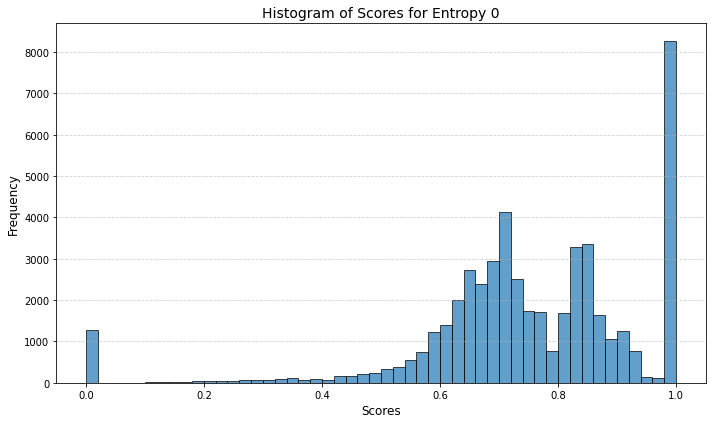

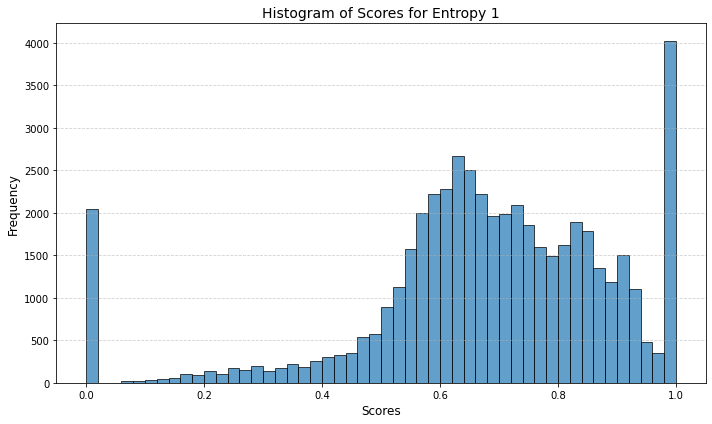

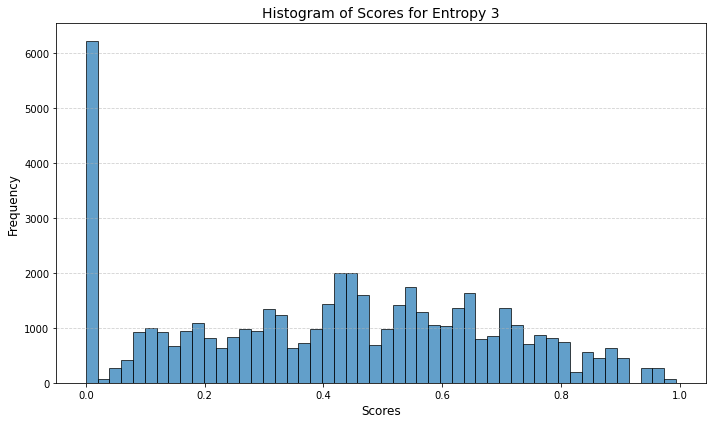

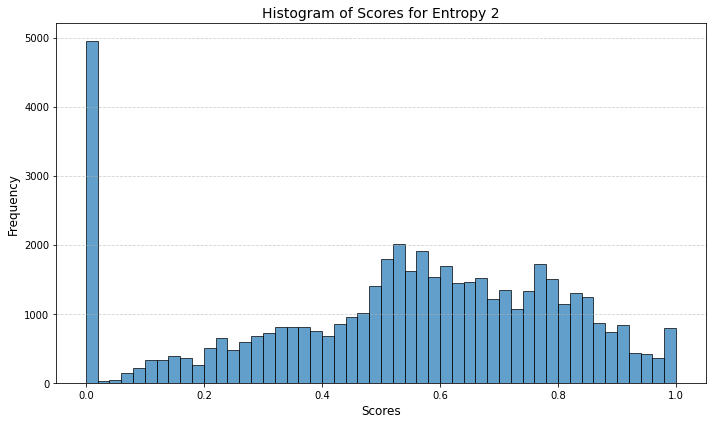

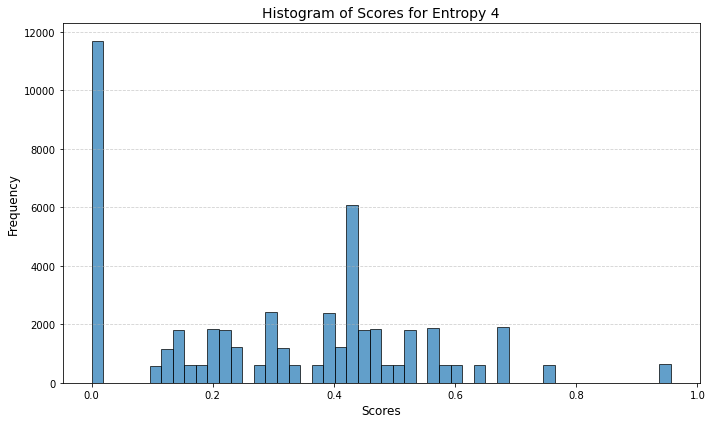

In [27]:
import matplotlib.pyplot as plt

# Iterate through entropy groups and plot histograms
for entropy, scores in formula_null_wo_onebond.items():
    plt.figure(figsize=(10, 6))
    plt.hist(scores, bins=50, alpha=0.7, edgecolor='black')
    
    # Add titles and labels
    plt.title(f"Histogram of Scores for Entropy {entropy}", fontsize=14)
    plt.xlabel("Scores", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    
    # Improve aesthetics
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()

    # Show the plot
    plt.show()


## Same but store sim = 1 pairs for manual inspection

In [29]:
import random
from collections import defaultdict
import numpy as np

def compute_random_similarity(isomer_pairs, num_pairs=100, num_bootstrap=100, ms2_tolerance_da=10):
    """
    Compute a null distribution of similarity scores from isomer pairs,
    stratified by the entropy of the first spectrum in each pair.

    Parameters:
      isomer_pairs (list of tuples): List of (spectrum1, spectrum2) isomer pairs.
      num_pairs (int): Number of random pairs to sample per entropy group per bootstrap iteration.
      num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates.
      ms2_tolerance_da (float): Tolerance in Daltons for entropy similarity calculation.

    Returns:
      dict: Null distributions of similarity scores grouped by spectral entropy.
      pd.DataFrame: DataFrame of high-similarity (similarity = 1) pairs for manual inspection.
    """
    entropy_groups = defaultdict(list)
    high_similarity_pairs = []

    # Group isomer pairs by the rounded entropy of the first spectrum
    for spec1, spec2 in isomer_pairs:
        peaks1_raw = spec1.get('peaks')
        peaks2_raw = spec2.get('peaks')

        try:
            parsed_peaks1 = safe_parse_peaks(peaks1_raw)
            parsed_peaks2 = safe_parse_peaks(peaks2_raw)
        except Exception as e:
            print(f"Error parsing peaks: {e}")
            continue

        spec1['peaks'] = parsed_peaks1
        spec2['peaks'] = parsed_peaks2

        if isinstance(parsed_peaks1, (list, np.ndarray)) and isinstance(parsed_peaks2, (list, np.ndarray)):
            # Compute entropy from first spectrum's peaks
            entropy1 = me.calculate_spectral_entropy(np.array(parsed_peaks1, dtype=np.float32),
                                                      clean_spectrum=True,
                                                      min_ms2_difference_in_da=0.05)
            entropy_group = round(entropy1)
            entropy_groups[entropy_group].append((spec1, spec2))

    print(f"Total entropy bins: {len(entropy_groups)}")

    # Create the null distributions by bootstrapping from each entropy group
    null_distributions = defaultdict(list)

    for entropy, pairs in entropy_groups.items():
        if len(pairs) < 2:
            continue  # Skip groups with too few pairs

        for _ in range(num_bootstrap):
            selected_pairs = random.choices(pairs, k=num_pairs) if len(pairs) < num_pairs else random.sample(pairs, num_pairs)

            for spec1, spec2 in selected_pairs:
                similarity = me.calculate_entropy_similarity(spec1['peaks'], spec2['peaks'], ms2_tolerance_in_da=ms2_tolerance_da)
                null_distributions[entropy].append(similarity)

                # Store high similarity pairs for manual review
                if similarity == 1:
                    high_similarity_pairs.append({
                        "similarity": similarity,
                        "formula": spec1["Formula"],
                        "inchi14_query": spec1["inchi14"],
                        "inchi14_library": spec2["inchi14"],
                        "spec_id_query": spec1["Spectrum ID"],
                        "spec_id_library": spec2["Spectrum ID"],
                        "smiles_query": spec1["SMILES"],
                        "smiles_library":spec2["SMILES"]
                    })

    # Convert high similarity pairs to DataFrame
    import pandas as pd
    df_high_sim = pd.DataFrame(high_similarity_pairs)

    return null_distributions, df_high_sim


In [30]:

formula_null, df_high_sim = compute_random_similarity(filtered_isomer_pairs, num_pairs=500, num_bootstrap=10)


Total entropy bins: 5


In [31]:
df_high_sim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   similarity       184 non-null    float64
 1   formula          184 non-null    object 
 2   inchi14_query    184 non-null    object 
 3   inchi14_library  184 non-null    object 
 4   spec_id_query    184 non-null    int64  
 5   spec_id_library  184 non-null    int64  
 6   smiles_query     184 non-null    object 
 7   smiles_library   184 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 11.6+ KB


In [32]:
# compute tanimoto similarity for those high-similarity pairs



from rdkit import Chem
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# Initialize Morgan fingerprint generator
morgan_gen = GetMorganGenerator(radius=2, fpSize=1024)

def calculate_tanimoto_similarity(smiles1, smiles2):
    """
    Compute the Tanimoto similarity between two molecules given their SMILES strings.

    Parameters:
        smiles1 (str): SMILES representation of the first molecule.
        smiles2 (str): SMILES representation of the second molecule.

    Returns:
        float: Tanimoto similarity score (0-1), or None if computation fails.
    """
    try:
        mol1 = Chem.MolFromSmiles(smiles1)
        mol2 = Chem.MolFromSmiles(smiles2)

        if mol1 is None or mol2 is None:
            return None  # Skip invalid molecules

        # Generate Morgan fingerprints using new method
        fp1 = morgan_gen.GetFingerprint(mol1)
        fp2 = morgan_gen.GetFingerprint(mol2)

        return TanimotoSimilarity(fp1, fp2)
    except Exception as e:
        print(f"Error computing Tanimoto similarity: {e}")
        return None

# Compute Tanimoto similarity for df_high_sim using SMILES columns
df_high_sim["tanimoto_similarity"] = df_high_sim.apply(
    lambda row: calculate_tanimoto_similarity(row["smiles_query"], row["smiles_library"]), axis=1
)


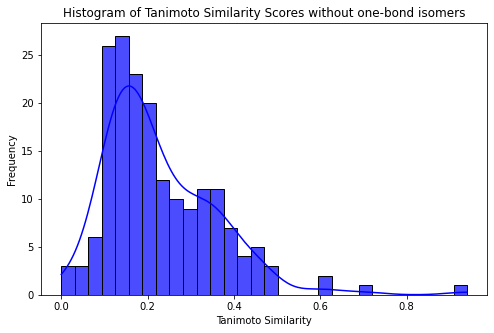

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram of Tanimoto similarity scores
plt.figure(figsize=(8, 5))
sns.histplot(df_high_sim["tanimoto_similarity"], bins=30, kde=True, color="blue", alpha=0.7)

plt.xlabel("Tanimoto Similarity")
plt.ylabel("Frequency")
plt.title("Histogram of Tanimoto Similarity Scores without one-bond isomers")
plt.show()


# Finding: although they are "spectrally similar", they are not "structurally similar", Tanimoto similarity provide another layer of information!

In [11]:
import itertools
# Group by "Formula"
grouped = df_unique.groupby(["Formula"])

# List to hold the isomer pairs
isomer_pairs = []

# Iterate over each group
for _, group in grouped:
    # Only consider groups with at least two entries
    if len(group) > 1:
        # Generate all unique pairs within the group
        for (idx1, row1), (idx2, row2) in itertools.combinations(group.iterrows(), 2):
            # Check if the first 14 characters of InChIKey differ
            if row1["inchi14"] != row2["inchi14"]:
                isomer_pairs.append((row1, row2))

# isomer_pairs now contains tuples of rows (each tuple is a pair of isomers)
print(f"Found {len(isomer_pairs)} isomer pairs meeting the criteria.")


NameError: name 'df_unique' is not defined

In [108]:
df_high_sim_w_onebone_isomers, formula_null_w_onebond_isomers = compute_random_similarity(isomer_pairs, num_pairs=100, num_bootstrap=50)

Total entropy bins: 6


In [112]:
formula_null_w_onebond_isomers.head()

,similarity,formula,inchi14_query,inchi14_library,spec_id_query,spec_id_library,smiles_query,smiles_library
0,1.0,C16H12O5,DXYUAIFZCFRPTH,LKOJGSWUMISDOF,1077099,3174358,COc1cc2c(=O)c(-c3ccc(O)cc3)coc2cc1O,COc1c(O)cc2oc(-c3ccccc3)cc(=O)c2c1O
1,1.0,C7H7NO3,HYNQTSZBTIOFKH,AOJLDZLRTUWFFY,1657161,3149293,Nc1ccc(O)cc1C(=O)O,Cc1cc(O)c(C(=O)O)cn1
2,1.0,C20H30O5,YRTJDWROBKPZNV,PPYRMVKHPFIXEU,1219078,1131879,CCCCCC(=O)C=CC1C(O)CC(=O)C1CC=CCCCC(=O)O,CC(O)CCCC(O)C=CC1=C(CC=CCCCC(=O)O)C(=O)CC1
3,1.0,C17H14O4,MLYYOHQNXPDGGV,GUHXVSRRBMHSSC,1208893,1208999,COc1c(-c2ccccc2)oc2cccc(OC)c2c1=O,COc1cccc(-c2cc(=O)c3ccc(OC)cc3o2)c1
4,1.0,C8H7FN2,SNOXQSJLHWBCBF,RCBICGWTJATNNU,3229796,4330151,CNc1ccc(C#N)cc1F,Nc1cc(F)c2cc[nH]c2c1


In [113]:
# Compute Tanimoto similarity for df_high_sim using SMILES columns
formula_null_w_onebond_isomers["tanimoto_similarity"] = formula_null_w_onebond_isomers.apply(
    lambda row: calculate_tanimoto_similarity(row["smiles_query"], row["smiles_library"]), axis=1
)


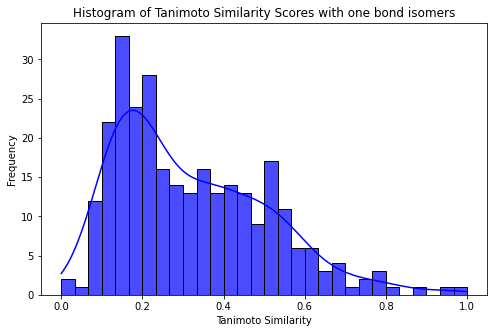

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram of Tanimoto similarity scores
plt.figure(figsize=(8, 5))
sns.histplot(formula_null_w_onebond_isomers["tanimoto_similarity"], bins=30, kde=True, color="blue", alpha=0.7)

plt.xlabel("Tanimoto Similarity")
plt.ylabel("Frequency")
plt.title("Histogram of Tanimoto Similarity Scores with one bond isomers")
plt.show()


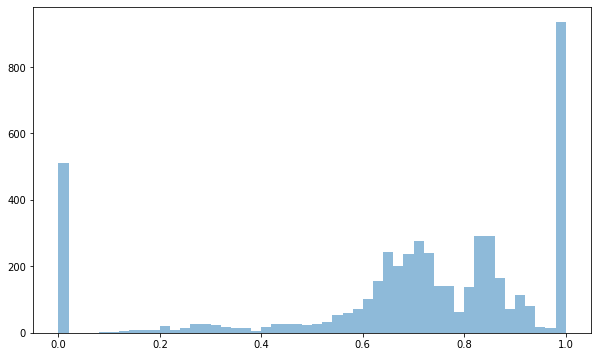

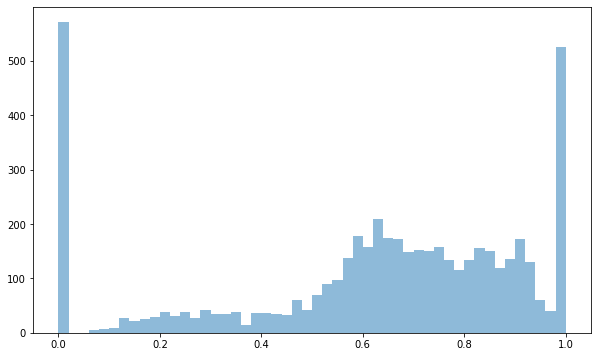

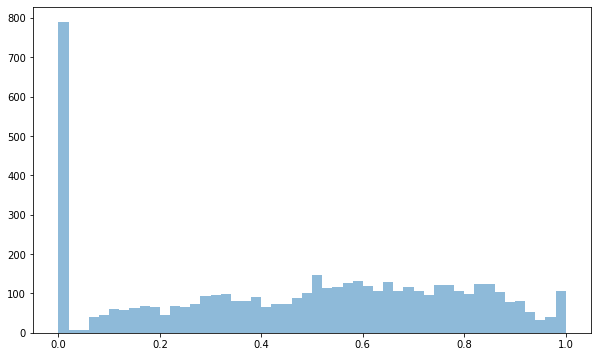

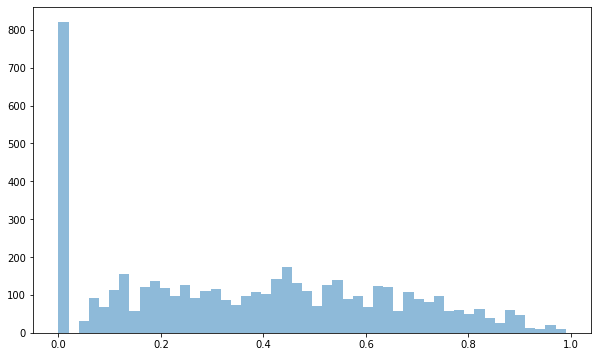

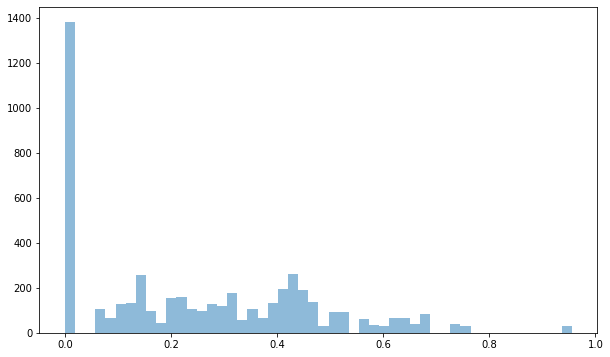

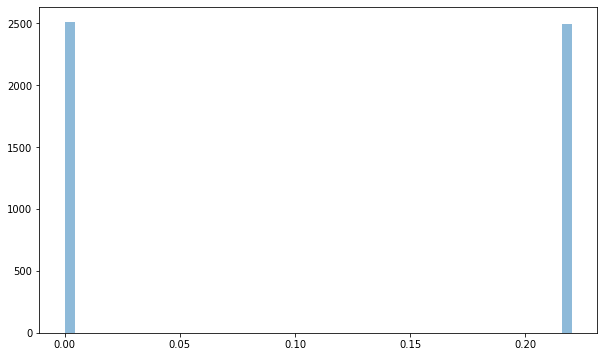

In [81]:

# Iterate through entropy groups and plot histograms
for entropy, scores in formula_null_w_onebond_isomers.items():
    plt.figure(figsize=(10, 6))
    plt.hist(scores, bins=50, alpha=0.5, label=f"Entropy {entropy}")


# Compute Tanimoto Weighted Null Instead

In [174]:
import random
from collections import defaultdict
import numpy as np
from rdkit import Chem
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# Initialize Morgan fingerprint generator
morgan_gen = GetMorganGenerator(radius=2, fpSize=1024)

def calculate_tanimoto_similarity(smiles1, smiles2):
    """
    Compute the Tanimoto similarity between two molecules given their SMILES strings.

    Parameters:
        smiles1 (str): SMILES representation of the first molecule.
        smiles2 (str): SMILES representation of the second molecule.

    Returns:
        float: Tanimoto similarity score (0-1), or None if computation fails.
    """
    try:
        mol1 = Chem.MolFromSmiles(smiles1)
        mol2 = Chem.MolFromSmiles(smiles2)

        if mol1 is None or mol2 is None:
            return None  # Skip invalid molecules

        # Generate Morgan fingerprints using the recommended method
        fp1 = morgan_gen.GetFingerprint(mol1)
        fp2 = morgan_gen.GetFingerprint(mol2)

        return TanimotoSimilarity(fp1, fp2)
    except Exception as e:
        print(f"Error computing Tanimoto similarity: {e}")
        return None

def compute_random_similarity(isomer_pairs, num_pairs=100, num_bootstrap=100, ms2_tolerance_da=10, lambda_factor=20):
    """
    Compute a null distribution of similarity scores from isomer pairs,
    incorporating Tanimoto similarity weighting to adjust for structural similarity.

    Parameters:
      isomer_pairs (list of tuples): List of (spectrum1, spectrum2) isomer pairs.
      num_pairs (int): Number of random pairs to sample per entropy group per bootstrap iteration.
      num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates.
      ms2_tolerance_da (float): MS2 tolerance in Daltons for entropy similarity calculation.
      lambda_factor (float): Controls the strength of Tanimoto penalty.

    Returns:
      dict: Null distributions of similarity scores grouped by spectral entropy.
      dict: Tanimoto similarity scores grouped by spectral entropy.
      pd.DataFrame: DataFrame of high-similarity (similarity = 1) pairs for manual inspection.
    """
    entropy_groups = defaultdict(list)
    high_similarity_pairs = []

    # Group isomer pairs by the rounded entropy of the first spectrum
    for spec1, spec2 in isomer_pairs:
        peaks1_raw = spec1.get('peaks')
        peaks2_raw = spec2.get('peaks')

        try:
            parsed_peaks1 = safe_parse_peaks(peaks1_raw)
            parsed_peaks2 = safe_parse_peaks(peaks2_raw)
        except Exception as e:
            print(f"Error parsing peaks: {e}")
            continue

        spec1['peaks'] = parsed_peaks1
        spec2['peaks'] = parsed_peaks2

        if isinstance(parsed_peaks1, (list, np.ndarray)) and isinstance(parsed_peaks2, (list, np.ndarray)):
            entropy1 = me.calculate_spectral_entropy(np.array(parsed_peaks1, dtype=np.float32),
                                                     clean_spectrum=True,
                                                     min_ms2_difference_in_da=0.05)
            entropy_group = round(entropy1)
            entropy_groups[entropy_group].append((spec1, spec2))

    print(f"Total entropy bins: {len(entropy_groups)}")

    # Create the null distributions by bootstrapping from each entropy group
    null_distributions = defaultdict(list)
    tanimoto_scores = defaultdict(list)

    for entropy, pairs in entropy_groups.items():
        if len(pairs) < 2:
            continue  # Skip groups with too few pairs

        for _ in range(num_bootstrap):
            selected_pairs = random.choices(pairs, k=num_pairs) if len(pairs) < num_pairs else random.sample(pairs, num_pairs)

            for spec1, spec2 in selected_pairs:
                similarity = me.calculate_entropy_similarity(spec1['peaks'], spec2['peaks'], ms2_tolerance_in_da=ms2_tolerance_da)

                # Compute Tanimoto similarity for structural similarity correction
                tanimoto_sim = calculate_tanimoto_similarity(spec1["SMILES"], spec2["SMILES"])
                tanimoto_sim = tanimoto_sim if tanimoto_sim is not None else 0

                null_distributions[entropy].append(similarity)
                tanimoto_scores[entropy].append(tanimoto_sim)

                # Store high similarity pairs for manual review
                if similarity == 1:
                    high_similarity_pairs.append({
                        "similarity": similarity,
                        "tanimoto_similarity": tanimoto_sim,
                        "formula": spec1["Formula"],
                        "inchi14_query": spec1["inchi14"],
                        "inchi14_library": spec2["inchi14"],
                        "spec_id_query": spec1["Spectrum ID"],
                        "spec_id_library": spec2["Spectrum ID"]
                    })

    # Convert high similarity pairs to DataFrame
    import pandas as pd
    df_high_sim = pd.DataFrame(high_similarity_pairs)

    return null_distributions, tanimoto_scores, df_high_sim



In [175]:
# Example Usage:
formula_null, null_tanimoto_scores, df_high_sim = compute_random_similarity(filtered_isomer_pairs, num_pairs=100, num_bootstrap=50)

Total entropy bins: 6


In [176]:
import numpy as np

def calculate_weighted_p_value(observed_similarity, null_similarities, null_tanimoto, lambda_factor=5):
    """
    Compute a weighted p-value for an observed similarity score using both similarity null and Tanimoto null.

    Parameters:
        observed_similarity (float): The similarity score to test.
        null_similarities (list): List of similarity scores from the similarity null.
        null_tanimoto (list): Corresponding Tanimoto similarity scores for null pairs.
        lambda_factor (float): Controls the strength of Tanimoto penalization (higher = more downweighting).

    Returns:
        float: Weighted p-value.
    """
    null_similarities = np.array(null_similarities)
    null_tanimoto = np.array(null_tanimoto)

    # Compute weight for each null pair (higher Tanimoto = lower weight)
    null_weights = np.exp(-lambda_factor * null_tanimoto)

    # Compute weighted probability of observing a similarity as extreme as observed_similarity
    weighted_count = np.sum(null_weights[null_similarities >= observed_similarity])
    total_weight = np.sum(null_weights)

    return weighted_count / total_weight if total_weight > 0 else 1.0


def calculate_weighted_p_values_for_all_entropy(null_distributions, observed_similarities, tanimoto_scores):
    """
    Compute weighted p-values for observed similarity scores across all entropy groups.

    Parameters:
        null_distributions (dict): Null distributions of similarity scores grouped by entropy.
        observed_similarities (dict): Observed similarity scores grouped by entropy.
        tanimoto_scores (dict): Tanimoto similarity scores grouped by entropy.

    Returns:
        dict: Weighted p-values for each entropy group.
    """
    weighted_p_values = {}
    for entropy in observed_similarities:
        if entropy in null_distributions and entropy in tanimoto_scores:
            null_sim = null_distributions[entropy]
            null_tani = tanimoto_scores[entropy]
            weighted_p_values[entropy] = calculate_weighted_p_value(observed_similarities[entropy], null_sim, null_tani)
    
    return weighted_p_values


def confidence_weighted_similarity(original_similarity, p_value, alpha=0.1, min_p=1e-5):
    """
    Compute confidence-weighted similarity with Tanimoto-adjusted p-value correction.

    Parameters:
        original_similarity (float): Raw entropy similarity score.
        p_value (float): Weighted p-value from the null distribution.
        alpha (float): Sigmoid scaling factor (reduce steepness).
        min_p (float): Minimum p-value to prevent log(0).

    Returns:
        float: Adjusted similarity score.
    """
    safe_p_value = max(p_value, min_p)  # Prevent log(0)
    
    # Less aggressive transformation using sigmoid
    transformed_p = 1 / (1 + np.exp(-alpha * (safe_p_value - 0.5)))  

    # Scale down the correction impact
    return original_similarity * (1 - transformed_p * 0.5)  # Less reduction


def compute_confidence_weighted_similarity(null_distributions, observed_similarities, tanimoto_scores):
    """
    Compute confidence-weighted similarity scores using weighted p-values and normalize them.

    Parameters:
        null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy.
        observed_similarities (dict): Observed similarity scores grouped by spectral entropy.
        tanimoto_scores (dict): Tanimoto similarity scores grouped by entropy.

    Returns:
        dict: Normalized confidence-weighted similarity scores.
    """
    weighted_p_values = calculate_weighted_p_values_for_all_entropy(null_distributions, observed_similarities, tanimoto_scores)
    weighted_similarities = {
        entropy: confidence_weighted_similarity(observed_similarities[entropy], weighted_p_values[entropy])
        for entropy in observed_similarities if entropy in weighted_p_values
    }

    # Normalize using adaptive scaling
    normalized_similarities = normalize_scores(weighted_similarities)

    return normalized_similarities


def compute_adjusted_similarity(df_results, null_distributions, tanimoto_scores):
    """
    Compute confidence-weighted similarity scores using weighted null distributions and add `adj_similarity` column.

    Parameters:
        df_results (pd.DataFrame): DataFrame containing similarity scores.
        null_distributions (dict): Null distributions of similarity scores.
        tanimoto_scores (dict): Tanimoto similarity scores grouped by entropy.

    Returns:
        pd.DataFrame: Updated DataFrame with adjusted similarity scores.
    """
    # Compute observed similarity scores per entropy bin
    observed_similarities = df_results.groupby("entropy_bin")["score_entropy"].mean().to_dict()

    # Compute adjusted scores using Tanimoto-weighted null distributions
    adjusted_scores = compute_confidence_weighted_similarity(null_distributions, observed_similarities, tanimoto_scores)
    
    # Apply adjusted similarity scores to dataframe
    df_results["adj_similarity"] = df_results["entropy_bin"].map(adjusted_scores)
    
    return df_results


In [177]:
def search_spectra_against_each_other(df_clean, null_distributions, tanimoto_scores, ms1_tolerance_ppm=10, ms2_tolerance_da=0.05):
    """
    Searches all spectra against each other within the given precursor m/z tolerance 
    and computes both entropy similarity score and adjusted similarity score incorporating Tanimoto similarity.
    
    Parameters:
    df_clean (pd.DataFrame): Cleaned DataFrame containing spectral data.
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy.
    tanimoto_scores (dict): Tanimoto similarity scores grouped by entropy.
    ms1_tolerance_ppm (float): Tolerance in parts-per-million for precursor m/z comparison.
    ms2_tolerance_da (float): Tolerance in Dalton for MS2 spectral comparison.
    
    Returns:
    pd.DataFrame: Results with entropy similarity scores, Tanimoto-adjusted similarity scores, and correctness labels.
    """
    df_clean = compute_spectral_entropy(df_clean)
    df_clean = df_clean.copy()
    df_clean.loc[:, "Exact Mass"] = df_clean["Exact Mass"].astype(float)
    df_clean = df_clean.sort_values(by="Exact Mass").reset_index(drop=True)

    precursor_mz_array = df_clean["Exact Mass"].values
    all_results = []
    
    for idx, row in df_clean.iterrows():
        precursor_mz = row["Exact Mass"]
        peaks = row["peaks"]
        inchikey = row["InChIKey"]
        spec_id = row["Spectrum ID"]
        entropy_bin = row["entropy_bin"]
        
        precursor_mz_left = precursor_mz * (1 - ms1_tolerance_ppm / 1e6)
        precursor_mz_right = precursor_mz * (1 + ms1_tolerance_ppm / 1e6)
        
        candidate_idx_left = np.searchsorted(precursor_mz_array, precursor_mz_left, side="left")
        candidate_idx_right = np.searchsorted(precursor_mz_array, precursor_mz_right, side="right")

        for candidate_idx in range(candidate_idx_left, candidate_idx_right):
            if candidate_idx == idx:
                continue  # Skip self-comparison

            candidate_row = df_clean.iloc[candidate_idx]
            candidate_peaks = candidate_row["peaks"]
            candidate_entropy_bin = candidate_row["entropy_bin"]

            entropy_similarity = ms_entropy.calculate_entropy_similarity(
                peaks, candidate_peaks, ms2_tolerance_in_da=ms2_tolerance_da
            )

            all_results.append([
                spec_id, inchikey, candidate_row["Spectrum ID"], candidate_row["InChIKey"], 
                entropy_similarity, entropy_bin
            ])

    df_results = pd.DataFrame(all_results, columns=[
        "spec_id_query", "inchikey_query", "spec_id_library", "inchikey_library", "score_entropy", "entropy_bin"
    ])

    # Compute Tanimoto-adjusted p-values for each individual observation
    df_results["weighted_p_value"] = df_results.apply(
        lambda row: calculate_weighted_p_value(
            row["score_entropy"], 
            null_distributions.get(row["entropy_bin"], []),  # Get null distribution for that entropy bin
            tanimoto_scores.get(row["entropy_bin"], []),  # Get Tanimoto null for that entropy bin
        ), axis=1
    )

    # Compute adjusted similarity scores using Tanimoto-weighted p-values
    df_results["adj_similarity"] = df_results.apply(
        lambda row: confidence_weighted_similarity(row["score_entropy"], row["weighted_p_value"]),
        axis=1
    )

    # Assign correctness label
    df_results["correct"] = df_results["inchikey_query"].astype(str) == df_results["inchikey_library"].astype(str)

    # Keep only the row with the highest score_entropy per spec_id_query and inchikey_library
    df_results = df_results.sort_values(by="score_entropy", ascending=False)
    df_results = df_results.groupby(["spec_id_query", "inchikey_library"]).first().reset_index()
    
    return df_results


In [157]:
# df_sample = df_clean.sample(n = 50000)

In [158]:
# search_spectra_against_each_other(df_sample, formula_null, null_tanimoto_scores, ms1_tolerance_ppm=10, ms2_tolerance_da=0.05)

In [178]:
df_results_new = search_spectra_against_each_other(df_sample, formula_null, null_tanimoto_scores, ms1_tolerance_ppm=10, ms2_tolerance_da=0.05)

In [179]:
df_results_new['correct'].value_counts()

correct
False    162763
True      34156
Name: count, dtype: int64

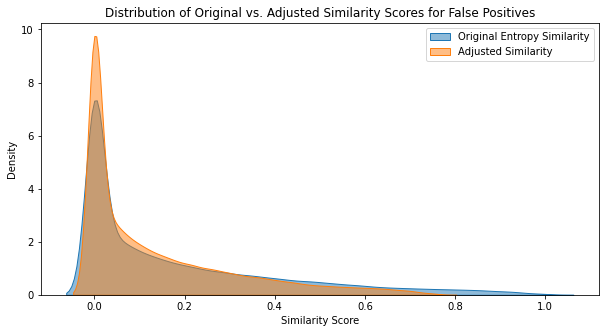

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only incorrect matches 
df_tp = df_results_new[df_results_new["correct"] == False]

# Plot the distribution of adjusted similarity vs. original similarity
plt.figure(figsize=(10, 5))
sns.kdeplot(df_tp["score_entropy"], label="Original Entropy Similarity", fill=True, alpha=0.5)
sns.kdeplot(df_tp["adj_similarity"], label="Adjusted Similarity", fill=True, alpha=0.5)

plt.xlabel("Similarity Score")
plt.ylabel("Density")
plt.title("Distribution of Original vs. Adjusted Similarity Scores for False Positives")
plt.legend()
plt.show()

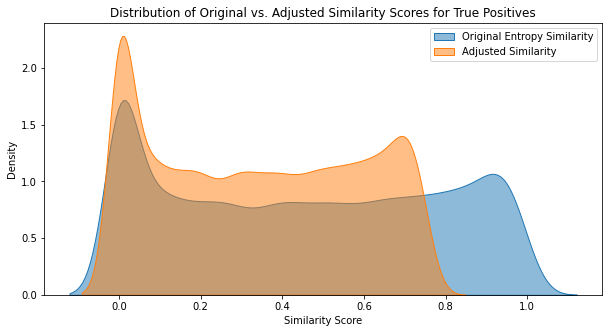

In [181]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only correct matches 
df_tp = df_results_new[df_results_new["correct"] == True]

# Plot the distribution of adjusted similarity vs. original similarity
plt.figure(figsize=(10, 5))
sns.kdeplot(df_tp["score_entropy"], label="Original Entropy Similarity", fill=True, alpha=0.5)
sns.kdeplot(df_tp["adj_similarity"], label="Adjusted Similarity", fill=True, alpha=0.5)

plt.xlabel("Similarity Score")
plt.ylabel("Density")
plt.title("Distribution of Original vs. Adjusted Similarity Scores for True Positives")
plt.legend()
plt.show()

In [182]:
# Rank original and adjusted similarity
df_results_new["rank_entropy"] = df_results_new["score_entropy"].rank(ascending=False)
df_results_new["rank_adj_similarity"] = df_results_new["adj_similarity"].rank(ascending=False)

# Compute correlation between rankings
rank_corr = df_results_new[["rank_entropy", "rank_adj_similarity"]].corr().iloc[0, 1]
print(f"Correlation between original and adjusted ranking: {rank_corr:.3f}")


Correlation between original and adjusted ranking: 1.000


In [185]:
import numpy as np

scaling_factor = np.mean(df_results_new["adj_similarity"] / df_results_new["score_entropy"])
print(f"Scaling Factor: {scaling_factor:.3f}")


Scaling Factor: 0.748


In [187]:
df_results_new["weighted_p_value"].describe()

count    196919.000000
mean          0.744744
std           0.277691
min           0.000000
25%           0.643760
50%           0.825471
75%           1.000000
max           1.000000
Name: weighted_p_value, dtype: float64

In [183]:
tp_rate_entropy = df_results_new[df_results_new["correct"] == True]["score_entropy"].mean()
tp_rate_adj_similarity = df_results_new[df_results_new["correct"] == True]["adj_similarity"].mean()

print(f"TP Rate Before Adjustment: {tp_rate_entropy:.3f}")
print(f"TP Rate After Adjustment: {tp_rate_adj_similarity:.3f}")


TP Rate Before Adjustment: 0.453
TP Rate After Adjustment: 0.341


In [184]:
fp_rate_entropy = df_results_new[df_results_new["correct"] == False]["score_entropy"].mean()
fp_rate_adj_similarity = df_results_new[df_results_new["correct"] == False]["adj_similarity"].mean()

print(f"TP Rate Before Adjustment: {fp_rate_entropy:.3f}")
print(f"TP Rate After Adjustment: {fp_rate_adj_similarity:.3f}")


TP Rate Before Adjustment: 0.182
TP Rate After Adjustment: 0.136


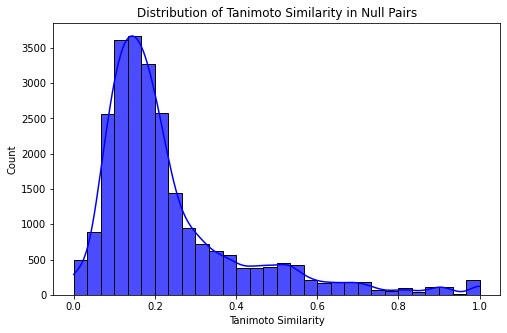

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot([score for scores in tanimoto_scores.values() for score in scores], bins=30, kde=True, color="blue", alpha=0.7)
plt.xlabel("Tanimoto Similarity")
plt.ylabel("Count")
plt.title("Distribution of Tanimoto Similarity in Null Pairs")
plt.show()


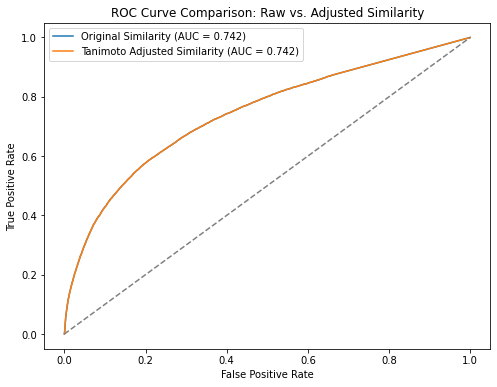

In [172]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_true, scores, label):
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

plt.figure(figsize=(8, 6))
plot_roc_curve(df_results_new["correct"], df_results_new["score_entropy"], "Original Similarity")
plot_roc_curve(df_results_new["correct"], df_results_new["adj_similarity"], "Tanimoto Adjusted Similarity")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Raw vs. Adjusted Similarity")
plt.legend()
plt.show()


In [168]:
print(df_results_new.head())

   spec_id_query inchikey_library  inchikey_query  spec_id_library  \
0        1035220   SNKAWJBJQDLSFF  SNKAWJBJQDLSFF          1035224   
1        1035224   SNKAWJBJQDLSFF  SNKAWJBJQDLSFF          1035220   
2        1035268   JLPULHDHAOZNQI  NVWYLRLKCCCUBZ          1529755   
3        1035268   LPXFOQGBESUDAX  NVWYLRLKCCCUBZ          1150628   
4        1035268   NVWYLRLKCCCUBZ  NVWYLRLKCCCUBZ          1035274   

   score_entropy entropy_bin  weighted_p_value  adj_similarity  correct  
0       0.865801           1          0.172296        0.652897     True  
1       0.865801           1          0.172296        0.652897     True  
2       0.000000           1          1.000000        0.000000    False  
3       0.292158           1          0.810162        0.217986    False  
4       0.905111           1          0.129758        0.683021     True  


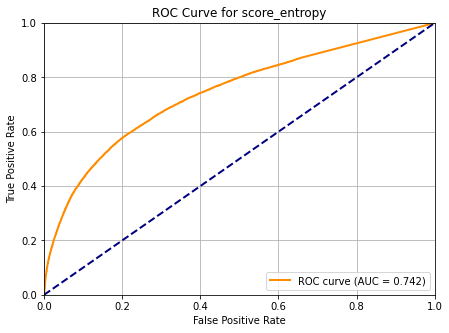

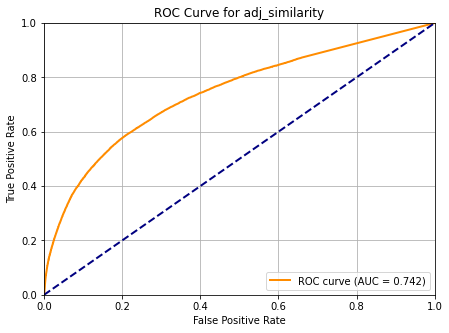

In [162]:
import matplotlib.pyplot as plt
from sklearn import metrics

def plot_roc_curve(df_results, score_column="score_entropy"):
    """
    Plot the ROC curve for a given similarity score in predicting correct matches.

    Parameters:
    df_results (pd.DataFrame): DataFrame containing the similarity scores and correctness labels.
    score_column (str): The column name containing similarity scores (e.g., "score_entropy" or "adj_similarity").
    """
    # Ensure no NaNs in the selected score column
    df_results = df_results.dropna(subset=[score_column])
    
    # Extract true labels and scores
    y_true = df_results["correct"].astype(int)  # Convert boolean to 0/1
    y_scores = df_results[score_column]
    
    # Compute ROC curve
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_scores)
    roc_auc = metrics.auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")  # Diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve for {score_column}")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

# Example usage:
plot_roc_curve(df_results_new, score_column="score_entropy")  # For entropy similarity score
plot_roc_curve(df_results_new, score_column="adj_similarity")  # For adjusted similarity score


# +-10 ppm null

In [17]:
import itertools
import numpy as np
import random
from collections import defaultdict

# Function to compute null distribution using ±10 ppm pairs
def compute_null_distribution_ppm(df_unique, num_pairs=100, num_bootstrap=100, ppm_tolerance=10):
    """
    Compute a null distribution of similarity scores using ±10 ppm pairs,
    stratified by the entropy of the first spectrum in each pair.

    Parameters:
      df_unique (DataFrame): DataFrame containing spectral data with 'PrecursorMZ' and 'peaks' columns.
      num_pairs (int): Number of random pairs to sample per entropy group per bootstrap iteration.
      num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates.
      ppm_tolerance (float): Precursor mass tolerance in ppm.

    Returns:
      dict: Null distributions of similarity scores grouped by spectral entropy.
    """
    entropy_groups = defaultdict(list)

    # Sort data by precursor mass for efficient ±10 ppm pairing
    df_sorted = df_unique.sort_values(by="Exact Mass").reset_index(drop=True)

    # List to hold ±10 ppm pairs
    ppm_pairs = []

    # Generate pairs within ±10 ppm window
    for i, row in df_sorted.iterrows():
        precursor_mz = row["Exact Mass"]
        mz_min = precursor_mz * (1 - ppm_tolerance / 1e6)
        mz_max = precursor_mz * (1 + ppm_tolerance / 1e6)

        # Find candidate spectra within the ±10 ppm window (excluding self-pairs)
        candidate_rows = df_sorted[(df_sorted["Exact Mass"] >= mz_min) & 
                                   (df_sorted["Exact Mass"] <= mz_max) &
                                   (df_sorted.index != i)]

        for _, candidate in candidate_rows.iterrows():
            ppm_pairs.append((row, candidate))

    print(f"Found {len(ppm_pairs)} pairs within ±{ppm_tolerance} ppm.")

    # Group by entropy
    for spec1, spec2 in ppm_pairs:
        peaks1_raw = spec1.get("peaks")
        peaks2_raw = spec2.get("peaks")

        try:
            parsed_peaks1 = safe_parse_peaks(peaks1_raw)
            parsed_peaks2 = safe_parse_peaks(peaks2_raw)
        except Exception as e:
            print(f"Error parsing peaks: {e}")
            continue

        spec1["peaks"] = parsed_peaks1
        spec2["peaks"] = parsed_peaks2

        if isinstance(parsed_peaks1, (list, np.ndarray)) and isinstance(parsed_peaks2, (list, np.ndarray)):
            entropy1 = me.calculate_spectral_entropy(np.array(parsed_peaks1, dtype=np.float32),
                                                     clean_spectrum=True,
                                                     min_ms2_difference_in_da=0.05)
            entropy_group = round(entropy1)
            entropy_groups[entropy_group].append((spec1, spec2))

    for entropy, pairs in entropy_groups.items():
        print(f"Entropy group {entropy} has {len(pairs)} pairs")

    # Create null distributions by bootstrapping from each entropy group
    null_distributions = defaultdict(list)

    for entropy, pairs in entropy_groups.items():
        if len(pairs) < 2:
            continue  # Skip groups with too few pairs

        for _ in range(num_bootstrap):
            if len(pairs) < num_pairs:
                selected_pairs = random.choices(pairs, k=num_pairs)
            else:
                selected_pairs = random.sample(pairs, num_pairs)

            scores = [
                me.calculate_entropy_similarity(spec1["peaks"], spec2["peaks"], ms2_tolerance_in_da=10)
                for spec1, spec2 in selected_pairs
            ]
            null_distributions[entropy].extend(scores)

    return null_distributions


In [19]:
mass_null = compute_null_distribution_ppm(df_unique,num_pairs=100, num_bootstrap=50, ppm_tolerance=2)

Found 160986 pairs within ±2 ppm.
Entropy group 1 has 60483 pairs
Entropy group 0 has 93261 pairs
Entropy group 2 has 6039 pairs
Entropy group 3 has 1098 pairs
Entropy group 4 has 104 pairs
Entropy group 5 has 1 pairs


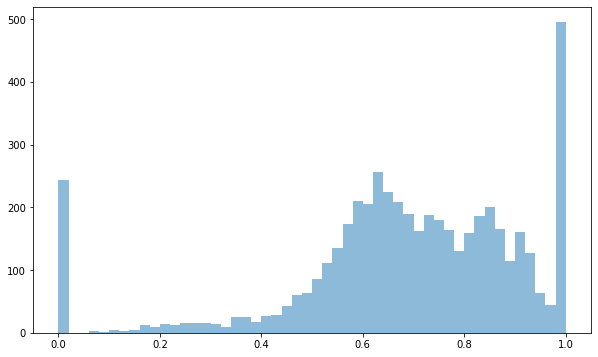

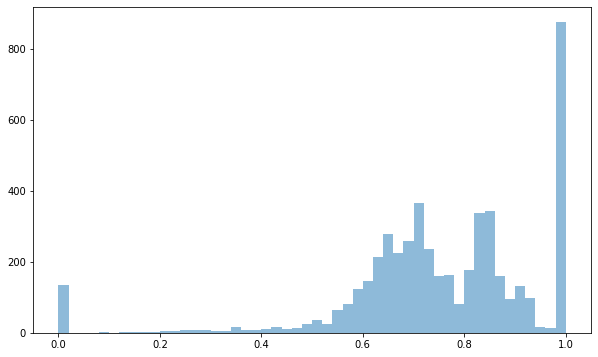

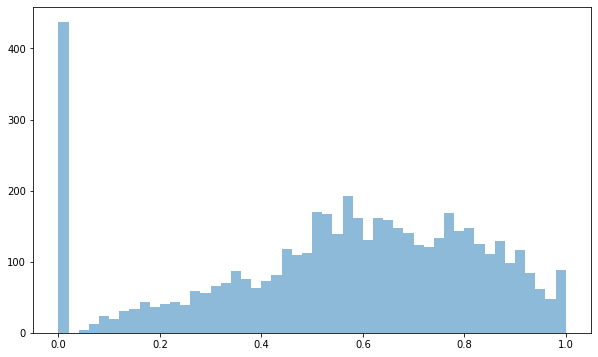

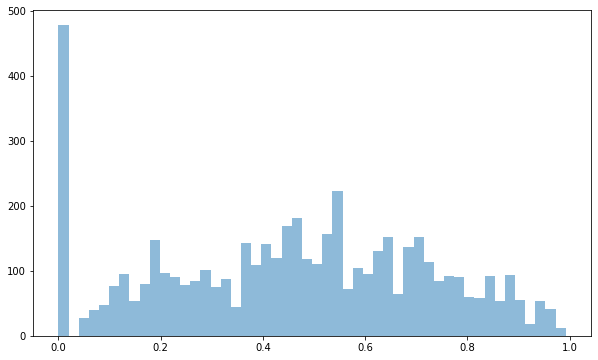

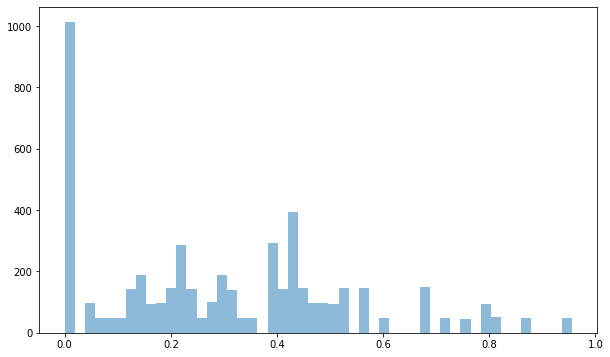

In [63]:

# Iterate through entropy groups and plot histograms
for entropy, scores in mass_null.items():
    plt.figure(figsize=(10, 6))
    plt.hist(scores, bins=50, alpha=0.5, label=f"Entropy {entropy}")


In [53]:
import numpy as np

def calculate_p_value(observed_similarity, null_distribution):
    """
    Compute one-sided p-value for a similarity score using the null distribution.

    Parameters:
    observed_similarity (float): Similarity score to test.
    null_distribution (list or numpy.ndarray): Null distribution of similarity scores.

    Returns:
    float: One-sided p-value.
    """
    null_distribution = np.array(null_distribution)
    p_value = np.mean(null_distribution >= observed_similarity)
    return p_value


def calculate_p_values_for_all_entropy(null_distributions, observed_similarities):
    """
    Compute p-values for observed similarity scores across all entropy groups.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by entropy.
    observed_similarities (dict): Observed similarity scores grouped by entropy.

    Returns:
    dict: P-values for each entropy group.
    """
    p_values = {
        entropy: calculate_p_value(observed_similarities[entropy], null_distribution)
        for entropy, null_distribution in null_distributions.items()
        if entropy in observed_similarities
    }
    return p_values


def confidence_weighted_similarity(original_similarity, p_value, alpha=0.1, min_p=1e-5):
    """
    Compute confidence-weighted similarity with softer p-value correction.
    
    Parameters:
    original_similarity (float): Raw entropy similarity score
    p_value (float): P-value from the null distribution
    alpha (float): Sigmoid scaling factor (reduce steepness)
    min_p (float): Minimum p-value to prevent log(0)
    
    Returns:
    float: Adjusted similarity score
    """
    safe_p_value = max(p_value, min_p)  # Prevent log(0)
    
    # Less aggressive transformation
    transformed_p = 1 / (1 + np.exp(-alpha * (safe_p_value - 0.5)))  

    # Scale down the correction impact
    return original_similarity * (1 - transformed_p * 0.5)  # Less reduction


def normalize_scores(weighted_similarities):
    """
    Normalize similarity scores adaptively to prevent excessive compression.
    
    Parameters:
    weighted_similarities (dict): Dictionary of confidence-weighted similarity scores.
    
    Returns:
    dict: Normalized similarity scores.
    """
    values = np.array(list(weighted_similarities.values()))
    mean_val, std_val = np.mean(values), np.std(values)

    if std_val == 0:
        return {entropy: 0.6 for entropy in weighted_similarities}  # Keep neutral instead of 0.5

    # Apply a wider normalization range
    normalized = {
        entropy: max(0, min(1, 0.4 + (score - mean_val) / (1.5 * std_val)))
        for entropy, score in weighted_similarities.items()
    }
    return normalized




def compute_confidence_weighted_similarity(null_distributions, observed_similarities):
    """
    Compute confidence-weighted similarity scores and normalize them.

    Parameters:
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy.
    observed_similarities (dict): Observed similarity scores grouped by spectral entropy.

    Returns:
    dict: Normalized confidence-weighted similarity scores.
    """
    p_values = calculate_p_values_for_all_entropy(null_distributions, observed_similarities)
    weighted_similarities = {
        entropy: confidence_weighted_similarity(observed_similarities[entropy], p_values[entropy])
        for entropy in observed_similarities if entropy in p_values
    }

    # Normalize using adaptive scaling
    normalized_similarities = normalize_scores(weighted_similarities)

    return normalized_similarities


def compute_adjusted_similarity(df_results, null_distributions):
    """
    Compute confidence-weighted similarity scores and add `adj_similarity` column.
    
    Parameters:
    df_results (pd.DataFrame): DataFrame containing similarity scores.
    null_distributions (dict): Null distributions of similarity scores.

    Returns:
    pd.DataFrame: Updated DataFrame with adjusted similarity scores.
    """
    observed_similarities = df_results.groupby("entropy_bin")["score_entropy"].mean().to_dict()
    adjusted_scores = compute_confidence_weighted_similarity(null_distributions, observed_similarities)
    
    df_results["adj_similarity"] = df_results["entropy_bin"].map(adjusted_scores)
    
    return df_results


In [17]:

# def search_spectra_against_each_other(df_clean, ms1_tolerance_ppm=10, ms2_tolerance_da=0.05):
#     """
#     Searches all spectra against each other within the given precursor m/z tolerance.
#     """
#     # Sort by Precursor M/Z
#     df_clean["Exact Mass"] = df_clean["Exact Mass"].astype(float)
#     df_clean = df_clean.sort_values(by="Exact Mass").reset_index(drop=True)
    
#     precursor_mz_array = df_clean["Exact Mass"].values
#     all_results = []
    
#     for idx, row in df_clean.iterrows():
#         precursor_mz = row["Exact Mass"]
#         peaks = row["peaks"]
#         inchikey = row["InChIKey"]
#         spec_id = row["Spectrum ID"]
        
#         precursor_mz_left = precursor_mz * (1 - ms1_tolerance_ppm / 1e6)
#         precursor_mz_right = precursor_mz * (1 + ms1_tolerance_ppm / 1e6)
        
#         candidate_idx_left = np.searchsorted(precursor_mz_array, precursor_mz_left, side="left")
#         candidate_idx_right = np.searchsorted(precursor_mz_array, precursor_mz_right, side="right")
        
#         # Search through candidate spectra
#         for candidate_idx in range(candidate_idx_left, candidate_idx_right):
#             if candidate_idx == idx:
#                 continue  # Skip self-comparison
                
#             candidate_row = df_clean.iloc[candidate_idx]
#             candidate_peaks = candidate_row["peaks"]
#             entropy_similarity = ms_entropy.calculate_entropy_similarity(peaks, candidate_peaks, ms2_tolerance_in_da=ms2_tolerance_da)
            
#             all_results.append([
#                 spec_id, inchikey, candidate_row["Spectrum ID"], candidate_row["InChIKey"], entropy_similarity
#             ])
    
#     df_results = pd.DataFrame(all_results, columns=["spec_id_query", "inchikey_query", "spec_id_library", "inchikey_library", "score_entropy"])
#     return df_results


In [54]:
import numpy as np
import pandas as pd
import ms_entropy

def compute_spectral_entropy(df_clean):
    """
    Compute spectral entropy for each spectrum and assign entropy bins based on rounded entropy values.

    Parameters:
    df_clean (pd.DataFrame): DataFrame containing spectral data with "peaks" column.

    Returns:
    pd.DataFrame: Updated DataFrame with computed spectral entropy and entropy bins.
    """
    df_clean = df_clean.copy()

    def calculate_entropy(peaks):
        if isinstance(peaks, list) and len(peaks) > 0:
            return ms_entropy.calculate_spectral_entropy(np.array(peaks))  
        return np.nan  

    df_clean.loc[:, "score_entropy"] = df_clean["peaks"].apply(calculate_entropy)
    df_clean.loc[:, "entropy_bin"] = df_clean["score_entropy"].round().astype("Int64")  

    return df_clean

def search_spectra_against_each_other(df_clean, null_distributions, ms1_tolerance_ppm=10, ms2_tolerance_da=0.05):
    """
    Searches all spectra against each other within the given precursor m/z tolerance 
    and computes both entropy similarity score and adjusted similarity score.
    
    Parameters:
    df_clean (pd.DataFrame): Cleaned DataFrame containing spectral data.
    null_distributions (dict): Null distributions of similarity scores grouped by spectral entropy.
    ms1_tolerance_ppm (float): Tolerance in parts-per-million for precursor m/z comparison.
    ms2_tolerance_da (float): Tolerance in Dalton for MS2 spectral comparison.
    
    Returns:
    pd.DataFrame: Results with entropy similarity scores, adjusted similarity scores, and correctness labels.
    """
    df_clean = compute_spectral_entropy(df_clean)
    df_clean = df_clean.copy()
    df_clean.loc[:, "Exact Mass"] = df_clean["Exact Mass"].astype(float)
    df_clean = df_clean.sort_values(by="Exact Mass").reset_index(drop=True)

    precursor_mz_array = df_clean["Exact Mass"].values
    all_results = []
    
    for idx, row in df_clean.iterrows():
        precursor_mz = row["Exact Mass"]
        peaks = row["peaks"]
        inchikey = row["InChIKey"]
        spec_id = row["Spectrum ID"]
        entropy_bin = row["entropy_bin"]
        
        precursor_mz_left = precursor_mz * (1 - ms1_tolerance_ppm / 1e6)
        precursor_mz_right = precursor_mz * (1 + ms1_tolerance_ppm / 1e6)
        
        candidate_idx_left = np.searchsorted(precursor_mz_array, precursor_mz_left, side="left")
        candidate_idx_right = np.searchsorted(precursor_mz_array, precursor_mz_right, side="right")

        for candidate_idx in range(candidate_idx_left, candidate_idx_right):
            if candidate_idx == idx:
                continue  # Skip self-comparison

            candidate_row = df_clean.iloc[candidate_idx]
            candidate_peaks = candidate_row["peaks"]
            candidate_entropy_bin = candidate_row["entropy_bin"]

            entropy_similarity = ms_entropy.calculate_entropy_similarity(
                peaks, candidate_peaks, ms2_tolerance_in_da=ms2_tolerance_da
            )

#             print(f"Query: {spec_id} ({inchikey}) | Candidate: {candidate_row['Spectrum ID']} ({candidate_row['InChIKey']}) | m/z: {candidate_row['Exact Mass']} | Similarity: {entropy_similarity}")

            all_results.append([
                spec_id, inchikey, candidate_row["Spectrum ID"], candidate_row["InChIKey"], 
                entropy_similarity, entropy_bin
            ])





    df_results = pd.DataFrame(all_results, columns=[
        "spec_id_query", "inchikey_query", "spec_id_library", "inchikey_library", "score_entropy", "entropy_bin"
    ])

    # Compute adjusted similarity scores
    observed_similarities = df_results.groupby("entropy_bin")["score_entropy"].mean().to_dict()
    adjusted_scores = compute_confidence_weighted_similarity(null_distributions, observed_similarities)
    df_results["adj_similarity"] = df_results["entropy_bin"].map(adjusted_scores)
    
    # Assign correctness label
#     print(df_results[["spec_id_query", "inchikey_query", "spec_id_library", "inchikey_library", "score_entropy"]].head(10))
    df_results["correct"] = df_results["inchikey_query"].astype(str) == df_results["inchikey_library"].astype(str)

    
    # Keep only the row with the highest score_entropy per spec_id_query and inchikey_library
    df_results = df_results.sort_values(by="score_entropy", ascending=False)
    df_results = df_results.groupby(["spec_id_query", "inchikey_library"]).first().reset_index()
    
    return df_results

In [22]:
df_clean["peaks"] = df_clean["peaks"].apply(safe_parse_peaks)

<ipython-input-22-2b711e6b4e0d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["peaks"] = df_clean["peaks"].apply(safe_parse_peaks)


In [23]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1934658 entries, 0 to 1934657
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Name            object 
 1   peaks           object 
 2   Precursor Type  object 
 3   Exact Mass      float64
 4   InChIKey        object 
 5   SMILES          object 
 6   Formula         object 
 7   Spectrum ID     int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 118.1+ MB


In [25]:
df_sample = df_clean.sample(n = 10000)

In [55]:
df_results = search_spectra_against_each_other(df_sample, mass_null, ms1_tolerance_ppm=10, ms2_tolerance_da=0.05)

In [56]:
df_results['correct'].value_counts()

correct
False    433454
True      85062
Name: count, dtype: int64

In [57]:
df_results[:10]

,spec_id_query,inchikey_library,inchikey_query,spec_id_library,score_entropy,entropy_bin,adj_similarity,correct
0,1035216,FORFDCPQKJHEBF,SNKAWJBJQDLSFF,1150389,0.515858,1,0.000000,False
1,1035277,JLPULHDHAOZNQI,NVWYLRLKCCCUBZ,1529767,0.000000,1,0.000000,False
2,1035277,LPXFOQGBESUDAX,NVWYLRLKCCCUBZ,1150627,0.000000,1,0.000000,False
3,1035289,RRVPPYNAZJRZFR,WTJKGGKOPKCXLL,1150430,0.164975,0,0.000000,False
4,1035289,WTJKGGKOPKCXLL,WTJKGGKOPKCXLL,1035296,0.735822,0,0.000000,True
5,1035296,RRVPPYNAZJRZFR,WTJKGGKOPKCXLL,1150430,0.477780,1,0.000000,False
6,1035296,WTJKGGKOPKCXLL,WTJKGGKOPKCXLL,1150306,0.856102,1,0.000000,True
7,1035315,ASWBNKHCZGQVJV,ASWBNKHCZGQVJV,1391093,0.139231,2,0.263024,True
8,1035325,HVAUUPRFYPCOCA,IHNKQIMGVNPMTC,1393606,0.219376,1,0.000000,False
9,1035325,IHNKQIMGVNPMTC,IHNKQIMGVNPMTC,1151136,0.190836,1,0.000000,True


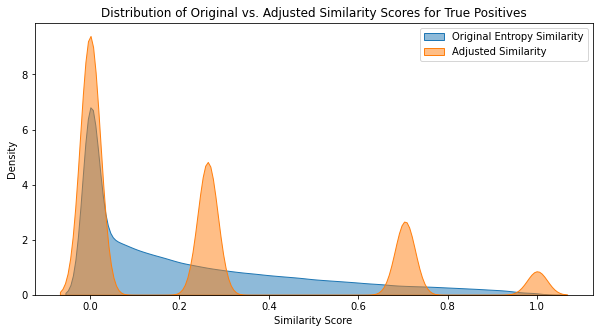

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only correct matches (true positives)
df_tp = df_results[df_results["correct"] == False]

# Plot the distribution of adjusted similarity vs. original similarity
plt.figure(figsize=(10, 5))
sns.kdeplot(df_tp["score_entropy"], label="Original Entropy Similarity", fill=True, alpha=0.5)
sns.kdeplot(df_tp["adj_similarity"], label="Adjusted Similarity", fill=True, alpha=0.5)

plt.xlabel("Similarity Score")
plt.ylabel("Density")
plt.title("Distribution of Original vs. Adjusted Similarity Scores for True Positives")
plt.legend()
plt.show()

In [59]:
# Compute key percentiles for true positives
percentiles = df_tp[["score_entropy", "adj_similarity"]].quantile([0.01, 0.25, 0.5, 0.75, 0.99])

# Display the percentiles
percentiles


,score_entropy,adj_similarity
0.01,0.000000,0.000000
0.25,0.281213,0.000000
0.50,0.600238,0.000000
0.75,0.836141,0.263024
0.99,0.997418,1.000000


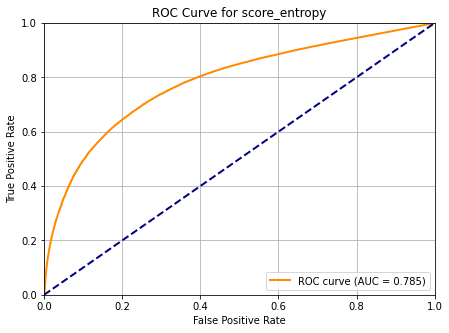

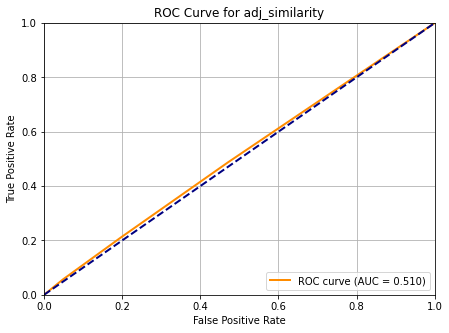

In [60]:
import matplotlib.pyplot as plt
from sklearn import metrics

def plot_roc_curve(df_results, score_column="score_entropy"):
    """
    Plot the ROC curve for a given similarity score in predicting correct matches.

    Parameters:
    df_results (pd.DataFrame): DataFrame containing the similarity scores and correctness labels.
    score_column (str): The column name containing similarity scores (e.g., "score_entropy" or "adj_similarity").
    """
    # Ensure no NaNs in the selected score column
    df_results = df_results.dropna(subset=[score_column])
    
    # Extract true labels and scores
    y_true = df_results["correct"].astype(int)  # Convert boolean to 0/1
    y_scores = df_results[score_column]
    
    # Compute ROC curve
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_scores)
    roc_auc = metrics.auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")  # Diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve for {score_column}")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

# Example usage:
plot_roc_curve(df_results, score_column="score_entropy")  # For entropy similarity score
plot_roc_curve(df_results, score_column="adj_similarity")  # For adjusted similarity score


In [38]:
df_tp = df_results[df_results["correct"] == True]


In [39]:
top_hits_raw = df_results.sort_values(by="score_entropy", ascending=False).groupby("spec_id_query").first()
top_hits_adj = df_results.sort_values(by="adj_similarity", ascending=False).groupby("spec_id_query").first()

tp_rate_raw = (top_hits_raw["correct"].sum() / len(top_hits_raw)) * 100
tp_rate_adj = (top_hits_adj["correct"].sum() / len(top_hits_adj)) * 100

print(f"TP rate before adjustment: {tp_rate_raw:.2f}%")
print(f"TP rate after adjustment: {tp_rate_adj:.2f}%")


TP rate before adjustment: 64.74%
TP rate after adjustment: 34.93%


In [40]:
mean_tp_raw = df_results[df_results["correct"] == True]["score_entropy"].mean()
mean_fp_raw = df_results[df_results["correct"] == False]["score_entropy"].mean()

mean_tp_adj = df_results[df_results["correct"] == True]["adj_similarity"].mean()
mean_fp_adj = df_results[df_results["correct"] == False]["adj_similarity"].mean()

print(f"Mean TP similarity (raw): {mean_tp_raw:.3f}")
print(f"Mean FP similarity (raw): {mean_fp_raw:.3f}")
print(f"Mean TP similarity (adjusted): {mean_tp_adj:.3f}")
print(f"Mean FP similarity (adjusted): {mean_fp_adj:.3f}")


Mean TP similarity (raw): 0.549
Mean FP similarity (raw): 0.217
Mean TP similarity (adjusted): 0.188
Mean FP similarity (adjusted): 0.177


# Hamming Distance and One bond different isomers

In [11]:
import signal
import time
from rdkit import Chem
from rdkit.Chem import DataStructs, rdFMCS
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import itertools

# Group molecules by molecular formula
grouped = df_unique.groupby(["Formula"])


In [ ]:
import signal
import time
from rdkit import Chem
from rdkit.Chem import DataStructs, rdFMCS
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import itertools

# Group molecules by molecular formula
grouped = df_unique.groupby(["Formula"])

# Timeout handling class
class TimeoutException(Exception):
    pass

def timeout_handler(signum, frame):
    raise TimeoutException()

signal.signal(signal.SIGALRM, timeout_handler)  # Register timeout handler

def one_bond_difference(mol1, mol2):
    """Check if two molecules differ by exactly one bond using an optimized MCS with pre-filters."""
    if not mol1 or not mol2:
        return False

    # Pre-filter 1: Bond count difference must be exactly 1
    bond_diff = abs(mol1.GetNumBonds() - mol2.GetNumBonds())
    if bond_diff != 1:
        return False

#     # Pre-filter 2: Tanimoto fingerprint similarity must be high (to avoid drastic changes)
#     fp_gen = GetMorganGenerator(radius=2, fpSize=1024)  # Use new RDKit API
#     fp1, fp2 = fp_gen.GetFingerprint(mol1), fp_gen.GetFingerprint(mol2)
    
#     if DataStructs.TanimotoSimilarity(fp1, fp2) < 0.9:
#         return False

    # Start the 30s timeout
    signal.alarm(30)
    
    try:
        # Compute MCS with optimized parameters
        mcs_start = time.time()
        mcs = rdFMCS.FindMCS(
            [mol1, mol2],
            bondCompare=rdFMCS.BondCompare.CompareOrder,  # Preserve bond order
            atomCompare=rdFMCS.AtomCompare.CompareElements,  # Compare elements strictly
            ringMatchesRingOnly=True,  # Match rings only to rings
            completeRingsOnly=True,  # Ensure full ring matches
            timeout=10  # Force stop after 10 seconds
        )
        mcs_time = time.time() - mcs_start
        signal.alarm(0)  # Disable alarm if successful

        common = Chem.MolFromSmarts(mcs.smartsString) if mcs.smartsString else None
        
        if common:
            bond_diff1 = mol1.GetNumBonds() - common.GetNumBonds()
            bond_diff2 = mol2.GetNumBonds() - common.GetNumBonds()
            
            return bond_diff1 == 1 and bond_diff2 == 1
    
    except TimeoutException:
        print(f"⚠️ WARNING: MCS computation exceeded 10s for this pair. Skipping...")
        signal.alarm(0)  # Reset alarm
        return False
    
    return False

# List to store only one-bond different isomer pairs
one_bond_isomers = []

for formula, group in grouped:
    group_start = time.time()
    if len(group) > 1:
        for (idx1, row1), (idx2, row2) in itertools.combinations(group.iterrows(), 2):
            if len(one_bond_isomers) >= 10000:  # Stop when 10000 pairs are collected
                break

            if row1["inchi14"] != row2["inchi14"]:  # Different first 14 InChIKeys
                mol1, mol2 = Chem.MolFromSmiles(row1["SMILES"]), Chem.MolFromSmiles(row2["SMILES"])
                
                # Ensure valid molecules before checking one-bond difference
                if mol1 and mol2 and one_bond_difference(mol1, mol2):
                    one_bond_isomers.append((row1, row2))
    
    group_time = time.time() - group_start
    print(f"Processing time for group {formula}: {group_time:.4f} seconds")
    
    if len(one_bond_isomers) >= 10000:  # Stop outer loop as well
        break

print(f"One-bond different isomer pairs: {len(one_bond_isomers)}")